In [30]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import scipy as sp
import seaborn as sns
import statsmodels.formula.api as smf

In [31]:
# Load CSV file into a dataframe
df = pd.read_csv(r"C:\Users\tmanuel\OneDrive - Cox Communications\Documents\Coursework\im310_v4_wk2_auto_accident_dataset.analysis.csv")

In [32]:
# Overview of data

df.describe()

,CASENUM,STRATUM,REGION,URBANICITY,NUM_INJ,NUM_INJ_CORR,MONTH,YEAR,DAY_WEEK,HOUR,MINUTE,HARM_EV,ALCOHOL,LGT_COND,INT_HWY,WEATHER,WKDY_IM,LGTCON_CORR,WEATHER_CORRECTED,
count,1.439000e+03,1439.000000,1439.000000,1439.000000,1439.000000,1409.000000,1439.000000,1439.0,1439.000000,1439.000000,1439.000000,1439.000000,1439.000000,1439.000000,1439.000000,1439.000000,1439.000000,1439.000000,1439.000000,0.0
mean,2.020022e+11,7.544823,2.845726,1.303683,2.833912,0.716820,1.004864,2020.0,4.241140,13.346769,28.262682,16.080612,4.218902,1.879083,0.123002,7.572620,4.241140,1.806810,2.857540,NaN
std,2.187705e+04,2.442789,0.584781,0.460007,14.305365,1.023867,0.184530,0.0,1.879049,7.059944,17.326102,11.083344,3.321030,1.297521,0.328554,20.887808,1.879049,1.108286,3.379538,NaN
min,2.020021e+11,2.000000,1.000000,1.000000,0.000000,0.000000,1.000000,2020.0,1.000000,0.000000,0.000000,1.000000,1.000000,1.000000,0.000000,1.000000,1.000000,1.000000,1.000000,NaN
25%,2.020021e+11,6.000000,3.000000,1.000000,0.000000,0.000000,1.000000,2020.0,3.000000,9.000000,15.000000,12.000000,2.000000,1.000000,0.000000,1.000000,3.000000,1.000000,1.000000,NaN
50%,2.020022e+11,8.000000,3.000000,1.000000,0.000000,0.000000,1.000000,2020.0,4.000000,14.000000,29.000000,12.000000,2.000000,1.000000,0.000000,1.000000,4.000000,1.000000,1.000000,NaN
75%,2.020022e+11,10.000000,3.000000,2.000000,1.000000,1.000000,1.000000,2020.0,6.000000,17.000000,43.000000,12.000000,9.000000,3.000000,0.000000,4.000000,6.000000,3.000000,2.000000,NaN
max,2.020022e+11,10.000000,4.000000,2.000000,99.000000,8.000000,8.000000,2020.0,7.000000,99.000000,99.000000,93.000000,9.000000,9.000000,1.000000,99.000000,7.000000,6.000000,12.000000,NaN


In [33]:
# Investigate correlation of alcohol and number of injuries
df.groupby('ALCOHOL')['NUM_INJ'].describe()

alcohol_df = df[df['ALCOHOL'].isin([1,2])]
alcohol_df.groupby(['ALCOHOL','URBANICITY'])['NUM_INJ'].describe()

count      mean        std  min  25%  50%   75%   max
ALCOHOL URBANICITY                                                       
1       1            49.0  1.346939   1.267396  0.0  0.0  1.0  2.00   6.0
        2            26.0  4.807692  19.235424  0.0  0.0  1.0  1.75  99.0
2       1           682.0  0.913490   3.924376  0.0  0.0  0.0  1.00  99.0
        2           215.0  0.469767   0.702311  0.0  0.0  0.0  1.00   4.0

In [34]:
# Look for outliers
alcohol_df[(alcohol_df['ALCOHOL'] == 1) & (alcohol_df['URBANICITY'] == 2)]['NUM_INJ'].sort_values(ascending=False).head(10)

1047    99
72       3
1129     3
161      3
775      2
839      2
1383     2
160      1
413      1
340      1
Name: NUM_INJ, dtype: int64

In [35]:
# Discovered that "99 injuries" is actually code for "unknown". Re-code "99 injuries" to "unknown"
df['NUM_INJ'] = df['NUM_INJ'].replace(99, pd.NA)
df['NUM_INJ'] = pd.to_numeric(df['NUM_INJ'], errors='coerce')

alcohol_df = df[df['ALCOHOL'].isin([1,2])]


In [36]:
# Re-examine data
alcohol_df.groupby(['ALCOHOL','URBANICITY'])['NUM_INJ'].describe()

count      mean       std  min  25%  50%  75%  max
ALCOHOL URBANICITY                                                    
1       1            49.0  1.346939  1.267396  0.0  0.0  1.0  2.0  6.0
        2            25.0  1.040000  0.978093  0.0  0.0  1.0  1.0  3.0
2       1           681.0  0.769457  1.119877  0.0  0.0  0.0  1.0  8.0
        2           215.0  0.469767  0.702311  0.0  0.0  0.0  1.0  4.0

In [37]:
# Create a summary table
injury_summary = (alcohol_df.groupby(['ALCOHOL','URBANICITY'])['NUM_INJ'].mean().reset_index())

injury_summary['ALCOHOL'] = injury_summary['ALCOHOL'].map({
    1: 'Alcohol Involved',
    2: 'No Alcohol'
})

injury_summary['URBANICITY'] = injury_summary['URBANICITY'].map({
    1: 'Urban',
    2: 'Rural'
})

print(injury_summary)

            ALCOHOL URBANICITY   NUM_INJ
0  Alcohol Involved      Urban  1.346939
1  Alcohol Involved      Rural  1.040000
2        No Alcohol      Urban  0.769457
3        No Alcohol      Rural  0.469767


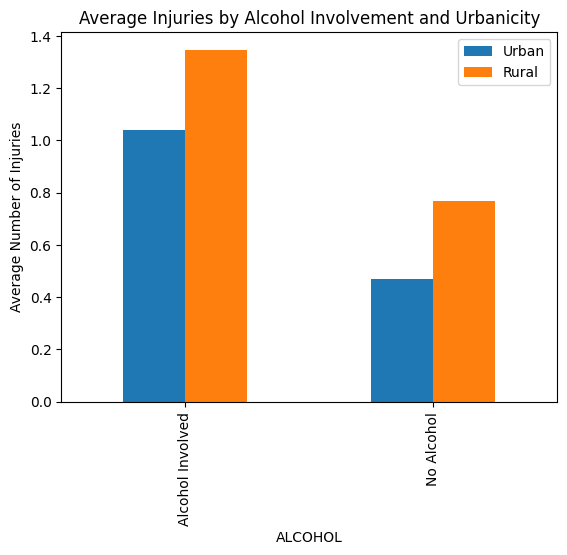

In [38]:
# Grouped bar chart
pivot = injury_summary.pivot(
    index = 'ALCOHOL',
    columns = 'URBANICITY',
    values = 'NUM_INJ'
)
pivot.plot(kind='bar')

plt.title('Average Injuries by Alcohol Involvement and Urbanicity')
plt.ylabel('Average Number of Injuries')
plt.legend(['Urban', 'Rural'])
plt.show()

<Axes: xlabel='ALCOHOL', ylabel='NUM_INJ'>

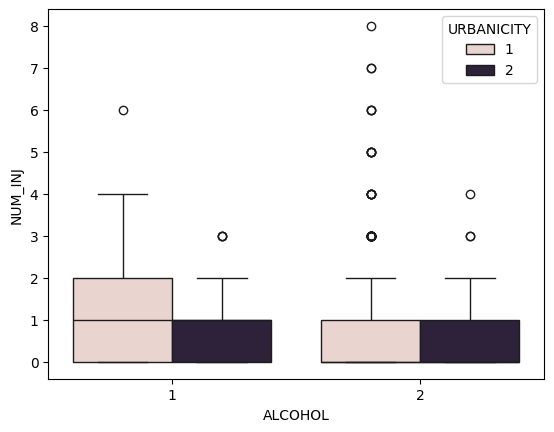

In [39]:
# Create a boxplot
sns.boxplot(x = 'ALCOHOL',
            y = 'NUM_INJ',
            hue = 'URBANICITY',
            data = alcohol_df
            )

In [40]:
# Investigate injury by region
df.groupby('REGION')['NUM_INJ'].describe()

,count,mean,std,min,25%,50%,75%,max
REGION,,,,,,,,
1,22.0,0.500000,0.963624,0.0,0.0,0.0,1.0,4.0
2,296.0,0.594595,0.842417,0.0,0.0,0.0,1.0,4.0
3,962.0,0.861746,3.307453,0.0,0.0,0.0,1.0,98.0
4,129.0,0.713178,1.160508,0.0,0.0,0.0,1.0,7.0


In [41]:
# Discovered that "98 injuries" is code for "No persons involved". Change "98 injuries" to "NAN"
df['NUM_INJ'] = df['NUM_INJ'].replace(98, pd.NA)
df['NUM_INJ'] = pd.to_numeric(df['NUM_INJ'], errors='coerce')

In [42]:
# Re-examine data
df.groupby('REGION')['NUM_INJ'].describe()

,count,mean,std,min,25%,50%,75%,max
REGION,,,,,,,,
1,22.0,0.500000,0.963624,0.0,0.0,0.0,1.0,4.0
2,296.0,0.594595,0.842417,0.0,0.0,0.0,1.0,4.0
3,961.0,0.760666,1.054234,0.0,0.0,0.0,1.0,8.0
4,129.0,0.713178,1.160508,0.0,0.0,0.0,1.0,7.0


In [43]:
# Swivel to examine injuries by alcohol, light condition, and weather
alcohol_light_weather_df = df[df['ALCOHOL'].isin([1,2]) & df['LGTCON_IM'].isin([1,2,3,4,5,6]) & df['WEATHER_CORRECTED'].isin([1,2,3,4,5,10,11,12])]
alcohol_light_weather_df.groupby(['ALCOHOL','LGTCON_IM','WEATHER_CORRECTED'])['NUM_INJ'].describe()

KeyError: 'LGTCON_IM'

In [ ]:
# Create a summary table for alcohol, light condition, and weather
alcohol_light_weather_summary = (alcohol_light_weather_df.groupby(['ALCOHOL','LGTCON_IM','WEATHER_CORRECTED'])['NUM_INJ'].mean().reset_index())
alcohol_light_weather_summary['ALCOHOL'] = alcohol_light_weather_summary['ALCOHOL'].map({
    1: 'Alcohol Involved',
    2: 'No Alcohol'
})
alcohol_light_weather_summary['LGTCON_IM'] = alcohol_light_weather_summary['LGTCON_IM'].map({
    1: 'Daylight',
    2: 'Dark - Not Lighted',
    3: 'Dark - Lighted',
    4: 'Dawn',
    5: 'Dusk',
    6: 'Dark - Unknown'
})
alcohol_light_weather_summary['WEATHER_CORRECTED'] = alcohol_light_weather_summary['WEATHER_CORRECTED'].map({
    1: 'Clear',
    2: 'Rain',
    3: 'Sleet/Hail',
    4: 'Snow',
    5: 'Fog/Smog/Smoke',
    10: 'Cloudy',
    11: 'Blowing Snow',
    12: 'Freezing Rain/Drizzle'
})
print(alcohol_light_weather_summary)

             ALCOHOL           LGTCON_IM WEATHER_CORRECTED   NUM_INJ
0   Alcohol Involved            Daylight             Clear  1.250000
1   Alcohol Involved            Daylight            Cloudy  0.333333
2   Alcohol Involved  Dark - Not Lighted             Clear  1.315789
3   Alcohol Involved  Dark - Not Lighted              Rain  1.333333
4   Alcohol Involved  Dark - Not Lighted              Snow  1.000000
5   Alcohol Involved  Dark - Not Lighted            Cloudy  3.000000
6   Alcohol Involved      Dark - Lighted             Clear  1.315789
7   Alcohol Involved      Dark - Lighted              Rain  0.333333
8   Alcohol Involved      Dark - Lighted            Cloudy  1.666667
9   Alcohol Involved                Dawn             Clear  1.000000
10  Alcohol Involved                Dawn            Cloudy  1.000000
11        No Alcohol            Daylight             Clear  0.666667
12        No Alcohol            Daylight              Rain  0.772727
13        No Alcohol            Da

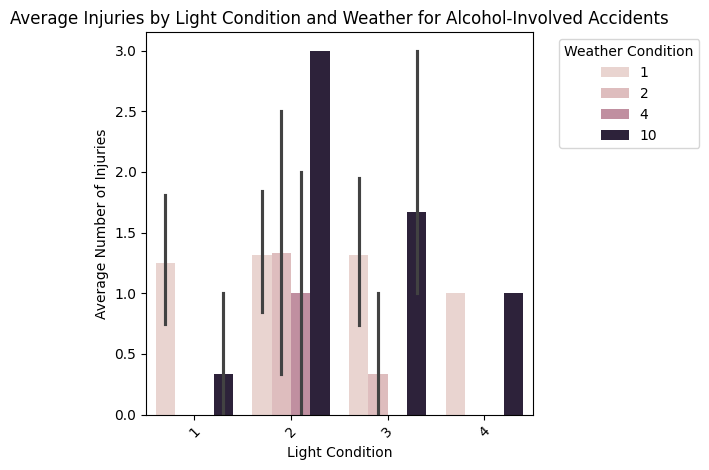

In [ ]:
# Visualize injuries by light condition and weather for alcohol-involved accidents
alcohol_involved_df = alcohol_light_weather_df[alcohol_light_weather_df['ALCOHOL'] == 1]
sns.barplot(x = 'LGTCON_IM',
            y = 'NUM_INJ',
            hue = 'WEATHER_CORRECTED',
            data = alcohol_involved_df
            )
plt.title('Average Injuries by Light Condition and Weather for Alcohol-Involved Accidents')
plt.ylabel('Average Number of Injuries')
plt.xlabel('Light Condition')
plt.legend(title='Weather Condition', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [ ]:
# Regression analysis to determine the effect of alcohol, urbanicity, region, and weather on the number of injuries
model = smf.ols('NUM_INJ ~ C(ALCOHOL) + C(URBANICITY) + C(REGION) + C(WEATHER_CORRECTED)', data = df).fit()

print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                NUM_INJ   R-squared:                       0.032
Model:                            OLS   Adj. R-squared:                  0.023
Method:                 Least Squares   F-statistic:                     3.553
Date:                Mon, 29 Jun 2026   Prob (F-statistic):           1.65e-05
Time:                        20:25:25   Log-Likelihood:                -2007.9
No. Observations:                1408   AIC:                             4044.
Df Residuals:                    1394   BIC:                             4117.
Df Model:                          13                                         
Covariance Type:            nonrobust                                         
                                 coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------------------
Intercept           